# TransUNet for Medical Image Classification
## Dataset: Skin Cancer Detection (Dermoscopy)

This notebook adapts **TransUNet** for **binary classification** of skin lesion images.
Dermoscopy is an entirely different imaging modality from X-ray and MRI,
making this the strongest cross-modality generalisation test in our study.

### Dataset
- Source: Skin Cancer: Malignant vs. Benign — Fanconic (Kaggle)
- Link: https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign
- Classes: Benign vs Malignant
- Size: 3,297 images (1,800 benign · 1,497 malignant)
- Modality: Dermoscopy

### Note on Dataset Selection
The originally planned ISIC 2020 dataset (~116GB) was not feasible for this study
due to Google Drive and Colab storage constraints on the free tier. We instead used
a curated dermoscopy dataset of 3,297 images covering the same binary classification
task (benign vs malignant), which is publicly available and fully reproducible
without institutional compute resources.

### Key difference from other notebooks
Unlike the TB, Pneumonia, and Brain Tumor notebooks which use folder-based datasets,
this dataset comes pre-split into train and test folders. Both splits are merged
and re-split 80/10/10 using the same random seed as all other experiments
to ensure a consistent and reproducible evaluation setup.

## Section 1: Setup & Installs

In [1]:
# connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install kagglehub
!pip install -q kagglehub

import kagglehub
import shutil


# Download the dataset (goes to a Colab cache folder first)
path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print(f"Downloaded to cache: {path}")

Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.
Downloaded to cache: /kaggle/input/skin-cancer-malignant-vs-benign


In [3]:
import shutil
import os

DEST = '/content/drive/MyDrive/TransUNet_Classification/Datasets/skin_cancer_dataset'
os.makedirs(DEST, exist_ok=True)

shutil.copytree(path, DEST, dirs_exist_ok=True)
print(os.listdir(DEST))

['data', 'test', 'train']


In [4]:


import os
import shutil

SOURCE = '/content/drive/MyDrive/TransUNet_Classification/Datasets/skin_cancer_dataset'
DEST   = '/content/drive/MyDrive/TransUNet_Classification/Datasets/skin_cancer_dataset_Merged'

classes =  ['benign', 'malignant']

for cls in classes:
    os.makedirs(os.path.join(DEST, cls), exist_ok=True)

for split in ['train', 'test']:
    for cls in classes:
        src_folder = os.path.join(SOURCE, split, cls)
        dst_folder = os.path.join(DEST, cls)

        if not os.path.exists(src_folder):
            print(f"WARNING: {src_folder} not found — check folder names")
            continue

        for img_file in os.listdir(src_folder):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src_path = os.path.join(src_folder, img_file)
                dst_path = os.path.join(dst_folder, f"{split}_{img_file}")
                shutil.copy2(src_path, dst_path)

# Confirm counts
print("\nMerged dataset:")
for cls in classes:
    count = len(os.listdir(os.path.join(DEST, cls)))
    print(f"  {cls}: {count} images")


Merged dataset:
  benign: 1800 images
  malignant: 1497 images


In [5]:
# Install required packages
!pip install -q timm ml_collections

# Clone TransUNet repo (provides the ViT + hybrid encoder)
!git clone https://github.com/Beckschen/TransUNet.git

print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.3 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 788.00 KiB/s, done.
Resolving deltas: 100% (71/71), done.
Done!


In [6]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# Add TransUNet to path
sys.path.insert(0, '/content/TransUNet')

from networks.vit_seg_modeling import VisionTransformer as ViT_seg
from networks.vit_seg_modeling import CONFIGS as VIT_CONFIGS

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Section 2: Configuration
**Only change this cell when adapting to a new dataset.**

In [7]:

DATASET_NAME   = 'skin-cancer'                       # used in plot titles & saved filenames
DATASET_PATH   = '/content/drive/MyDrive/TransUNet_Classification/Datasets/skin_cancer_dataset_Merged'
SAVE_DIR       = '/content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer'
CLASS_NAMES    = ['benign', 'malignant']
NUM_CLASSES    = 2
DATASET_TYPE   = 'folder'   # 'folder' = subfolders per class | 'csv' = ISIC-style CSV

# CSV-only fields (leave as None for folder datasets)
CSV_PATH       = None
IMG_DIR        = None
IMG_COL        = None   # column name for image filename in CSV
LABEL_COL      = None   # column name for label in CSV

# ============================================================
#  TRAINING CONFIG
# ============================================================
IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_EPOCHS     = 30
LEARNING_RATE  = 1e-4
RANDOM_SEED    = 42

# Paths for saved weights
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'metric_images'), exist_ok=True)

TRANSUNET_WEIGHTS = os.path.join(SAVE_DIR, f'transunet_{DATASET_NAME.lower()}_best.pth')
DENSENET_WEIGHTS  = os.path.join(SAVE_DIR, f'densenet_{DATASET_NAME.lower()}_best.pth')

print(f'Dataset      : {DATASET_NAME}')
print(f'Dataset path : {DATASET_PATH}')
print(f'Save dir     : {SAVE_DIR}')
print(f'Classes      : {CLASS_NAMES}')
print(f'Device       : {device}')

Dataset      : skin-cancer
Dataset path : /content/drive/MyDrive/TransUNet_Classification/Datasets/skin_cancer_dataset_Merged
Save dir     : /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer
Classes      : ['benign', 'malignant']
Device       : cuda


## Section 3: Dataset Loading

In [9]:
# ── Folder-based dataset (TB, Pneumonia, Brain Tumor) ──────────────────────
class FolderDataset(Dataset):
    """
    Loads images from a directory where each class has its own subfolder.
    Expected structure:
        root_dir/
            class_a/  img1.jpg  img2.png ...
            class_b/  img1.jpg  img2.png ...
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_folder):
                continue
            for img_file in os.listdir(cls_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(cls_folder, img_file), self.class_to_idx[cls]))

        print(f'Dataset loaded: {len(self.samples)} images | Classes: {self.class_to_idx}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, label


# ── CSV-based dataset (ISIC Melanoma) ──────────────────────────────────────
class CSVDataset(Dataset):
    """
    Loads images from a directory using a CSV manifest.
    Used for ISIC-style datasets where labels live in a CSV, not folder names.

    CSV must have at minimum:
        - img_col  : image filename (without extension, e.g. 'ISIC_0000000')
        - label_col: integer label (0 or 1)
    """
    def __init__(self, csv_path, img_dir, img_col, label_col, img_ext='.jpg', transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.img_col = img_col
        self.label_col = label_col
        self.img_ext = img_ext
        self.transform = transform
        print(f'CSV dataset loaded: {len(self.df)} images')
        print(f'Label distribution:\n{self.df[label_col].value_counts()}')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row[self.img_col]) + self.img_ext)
        image = Image.open(img_path).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Wrapper to apply different transforms to each split ────────────────────
class TransformSubset(Dataset):
    """Wraps a Subset and applies a transform to it."""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


print('Dataset classes defined!')

Dataset classes defined!


In [10]:
# Load the full dataset (no transforms yet — applied per split below)
if DATASET_TYPE == 'folder':
    full_dataset = FolderDataset(root_dir=DATASET_PATH, transform=None)
elif DATASET_TYPE == 'csv':
    full_dataset = CSVDataset(
        csv_path=CSV_PATH, img_dir=IMG_DIR,
        img_col=IMG_COL, label_col=LABEL_COL, transform=None
    )

# Explore class distribution
if DATASET_TYPE == 'folder':
    print('\nClass counts:')
    for cls in full_dataset.classes:
        cls_path = os.path.join(DATASET_PATH, cls)
        print(f'  {cls}: {len(os.listdir(cls_path))} images')

Dataset loaded: 3297 images | Classes: {'benign': 0, 'malignant': 1}

Class counts:
  benign: 1800 images
  malignant: 1497 images


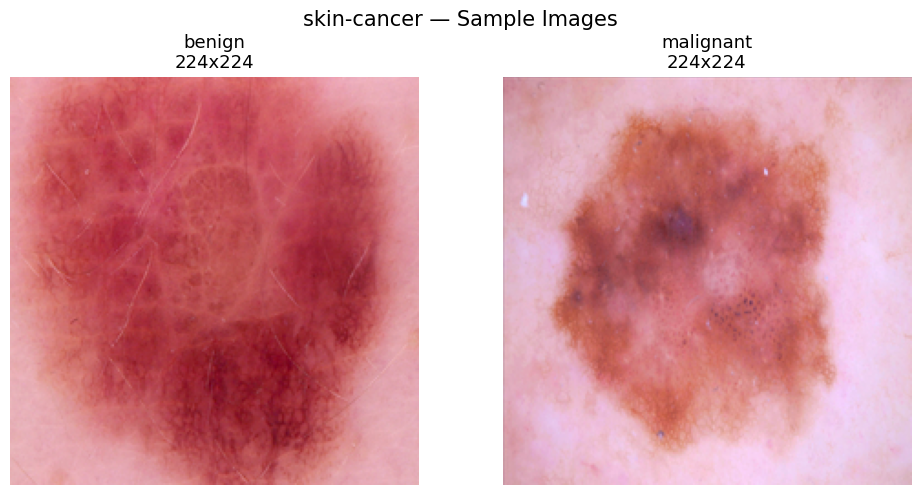

In [11]:
# Visualize one sample from each class
if DATASET_TYPE == 'folder':
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))
    if NUM_CLASSES == 2:
        axes = [axes] if NUM_CLASSES == 1 else axes
    for idx, cls in enumerate(full_dataset.classes):
        cls_path = os.path.join(DATASET_PATH, cls)
        sample_img = Image.open(os.path.join(cls_path, os.listdir(cls_path)[0]))
        axes[idx].imshow(sample_img, cmap='gray' if sample_img.mode == 'L' else None)
        axes[idx].set_title(f'{cls}\n{sample_img.size[0]}x{sample_img.size[1]}', fontsize=13)
        axes[idx].axis('off')
    plt.suptitle(f'{DATASET_NAME} — Sample Images', fontsize=15)
    plt.tight_layout()
    plt.show()

## Section 4: Preprocessing & Data Splits

In [12]:
# Training transforms — with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation / Test transforms — no augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split sizes: 80 / 10 / 10
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size   = int(0.1 * total_size)
test_size  = total_size - train_size - val_size

print(f'Total   : {total_size}')
print(f'Train   : {train_size}')
print(f'Val     : {val_size}')
print(f'Test    : {test_size}')

# Split with fixed seed for reproducibility
train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Attach transforms
train_dataset = TransformSubset(train_subset, transform=train_transforms)
val_dataset   = TransformSubset(val_subset,   transform=val_test_transforms)
test_dataset  = TransformSubset(test_subset,  transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Sanity check
images, labels = next(iter(train_loader))
print(f'\nBatch shape : {images.shape}')  # [32, 3, 224, 224]
print(f'Labels      : {labels[:8].tolist()}')

Total   : 3297
Train   : 2637
Val     : 329
Test    : 331

Train batches : 83
Val batches   : 11
Test batches  : 11

Batch shape : torch.Size([32, 3, 224, 224])
Labels      : [0, 0, 0, 0, 1, 1, 1, 0]


## Section 5: Model Architectures
### 5a: TransUNet Classifier (the novel contribution)

Standard TransUNet: ResNet50 encoder → ViT transformer → UNet decoder → segmentation output  
**Our adaptation:** ResNet50 encoder → ViT transformer → **Global Average Pooling → Classification head**

The decoder is discarded entirely. We pool over all patch token representations
(mean across the sequence dimension) to get a single feature vector, then classify.

In [13]:
class TransUNetClassifier(nn.Module):
    """
    TransUNet adapted for image classification.

    Architecture change vs original TransUNet:
    - Decoder (upsampling + segmentation head) is replaced by:
        1. Global Average Pooling over transformer patch tokens
        2. LayerNorm + Dropout + Linear classification head

    This allows the model to be used as a general-purpose classifier
    without any task-specific pretraining.

    Args:
        config      : TransUNet config (from VIT_CONFIGS)
        num_classes : number of output classes
        img_size    : input image size (default 224)
    """
    def __init__(self, config, num_classes=2, img_size=224):
        super(TransUNetClassifier, self).__init__()

        # Load the full TransUNet (we only use the encoder + transformer)
        self.transunet = ViT_seg(config, img_size=img_size, num_classes=num_classes)

        hidden_size = config.hidden_size  # 768 for ViT-B_16

        # Classification head replaces the segmentation decoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),     # stabilizes transformer outputs
            nn.Dropout(p=0.5),             # regularization
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        # Forward through ResNet encoder + ViT transformer
        # x: [batch, 3, H, W]
        x, attn_weights, features = self.transunet.transformer(x)
        # x: [batch, num_patches, hidden_size]

        # Global average pooling over patch tokens → [batch, hidden_size]
        # Alternative: use x[:, 0, :] if CLS token is available
        x = x.mean(dim=1)

        # Classify
        return self.classifier(x)


def build_transunet(num_classes=2, img_size=224):
    """Build and return a TransUNetClassifier with standard R50-ViT-B_16 config."""
    config = VIT_CONFIGS['R50-ViT-B_16']
    config.n_classes = num_classes
    config.n_skip = 3
    config.patches.grid = (img_size // 16, img_size // 16)  # e.g. 14x14 for 224
    config.pretrained_path = None  # training from scratch
    model = TransUNetClassifier(config, num_classes=num_classes, img_size=img_size)
    return model


print('TransUNetClassifier defined!')

TransUNetClassifier defined!


### 5b: DenseNet-121 Baseline

In [14]:
class DenseNetClassifier(nn.Module):
    """
    DenseNet-121 fine-tuned for binary/multi-class classification.
    Uses ImageNet pretrained weights — serves as the strong baseline.

    Args:
        num_classes : number of output classes
        pretrained  : use ImageNet pretrained weights (default True)
    """
    def __init__(self, num_classes=2, pretrained=True):
        super(DenseNetClassifier, self).__init__()
        self.model = models.densenet121(pretrained=pretrained)
        in_features = self.model.classifier.in_features  # 1024
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.model(x)


print('DenseNetClassifier defined!')

DenseNetClassifier defined!


## Section 6: Training Utilities

In [15]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Run one full training epoch. Returns (loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total * 100


def validate(model, loader, criterion):
    """Run validation (no gradient updates). Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total * 100


def run_training(model, model_name, save_path, num_epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    """
    Full training loop with early stopping via best-val-loss tracking.

    Returns:
        history (dict): train/val loss and accuracy per epoch
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    print(f'\n{"="*50}')
    print(f'Training: {model_name}')
    print(f'{"="*50}')

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc     = validate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}] | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%', end='')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(' ← best saved', end='')
        print()

    # Save history CSV
    hist_df = pd.DataFrame(history)
    hist_path = os.path.join(SAVE_DIR, f'{model_name.lower().replace(" ","_")}_history.csv')
    hist_df.to_csv(hist_path, index=False)

    print(f'\nTraining complete! Best val loss: {best_val_loss:.4f}')
    print(f'Weights saved to  : {save_path}')
    print(f'History saved to  : {hist_path}')
    return history


print('Training utilities ready!')

Training utilities ready!


## Section 7: Evaluation Utilities

In [16]:
def evaluate_model(model, weights_path, model_name):
    """
    Load best weights and evaluate on the test set.
    Returns dict of metrics and raw prediction arrays.
    """
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc     = accuracy_score(all_labels, all_preds) * 100
    f1      = f1_score(all_labels, all_preds, average='weighted') * 100
    auc_roc = roc_auc_score(all_labels, all_probs) * 100

    print(f'\n{"="*50}')
    print(f'  {model_name} — {DATASET_NAME} Test Results')
    print(f'{"="*50}')
    print(f'  Accuracy : {acc:.2f}%')
    print(f'  F1 Score : {f1:.2f}%')
    print(f'  AUC-ROC  : {auc_roc:.2f}%')
    print(f'{"="*50}')
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    return {
        'model_name': model_name,
        'accuracy':   acc,
        'f1':         f1,
        'auc_roc':    auc_roc,
        'preds':      all_preds,
        'labels':     all_labels,
        'probs':      all_probs
    }


print('Evaluation utilities ready!')

Evaluation utilities ready!


## Section 8: Visualization Utilities

In [17]:
def plot_training_history(history, model_name):
    """Plot and save loss + accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral',     linewidth=2)
    axes[0].set_title('Loss Over Epochs', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train Accuracy', color='steelblue', linewidth=2)
    axes[1].plot(history['val_acc'],   label='Val Accuracy',   color='coral',     linewidth=2)
    axes[1].set_title('Accuracy Over Epochs', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — {DATASET_NAME} Training History', fontsize=15)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f'{model_name.lower().replace(" ","_")}_training_history.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_confusion_matrix(results):
    """Plot and save confusion matrix."""
    cm = confusion_matrix(results['labels'], results['preds'])
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{results['model_name']} — {DATASET_NAME} Confusion Matrix", fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f"{results['model_name'].lower().replace(' ','_')}_confusion_matrix.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_roc_curve(results):
    """Plot and save ROC curve."""
    fpr, tpr, _ = roc_curve(results['labels'], results['probs'])
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f"AUC = {results['auc_roc']:.2f}%")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
    plt.title(f"{results['model_name']} — {DATASET_NAME} ROC Curve", fontsize=13)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images',
                             f"{results['model_name'].lower().replace(' ','_')}_roc_curve.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def plot_comparison(results_list):
    """Bar chart comparing models side by side on all three metrics."""
    model_names = [r['model_name'] for r in results_list]
    metrics = ['accuracy', 'f1', 'auc_roc']
    metric_labels = ['Accuracy (%)', 'F1 Score (%)', 'AUC-ROC (%)']
    colors = ['steelblue', 'coral']

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, result in enumerate(results_list):
        values = [result[m] for m in metrics]
        bars = ax.bar(x + i * width, values, width, label=result['model_name'], color=colors[i])
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
                    f'{val:.2f}%', ha='center', va='top', fontsize=10, color='white', fontweight='bold')

    ax.set_ylim([85, 102])
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title(f'Model Comparison — {DATASET_NAME}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(SAVE_DIR, 'metric_images', 'comparison_chart.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


print('Visualization utilities ready!')

Visualization utilities ready!


## Section 9: Train TransUNet

In [18]:
# Build the model
transunet_model = build_transunet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)

total_params = sum(p.numel() for p in transunet_model.parameters())
print(f'TransUNet total parameters: {total_params:,}')
print('Note: Training from scratch — no pretrained weights')

TransUNet total parameters: 105,279,140
Note: Training from scratch — no pretrained weights


In [19]:
transunet_history = run_training(
    model=transunet_model,
    model_name='TransUNet',
    save_path=TRANSUNET_WEIGHTS,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)


Training: TransUNet


Epoch [01/30] | Train Loss: 0.9214 Acc: 51.54% | Val Loss: 0.6559 Acc: 56.84% ← best saved


Epoch [02/30] | Train Loss: 0.5379 Acc: 72.70% | Val Loss: 0.4517 Acc: 77.20% ← best saved


Epoch [03/30] | Train Loss: 0.4226 Acc: 79.75% | Val Loss: 0.4300 Acc: 76.60% ← best saved


Epoch [04/30] | Train Loss: 0.4145 Acc: 80.32% | Val Loss: 0.4265 Acc: 77.51% ← best saved


...

Epoch [26/30] | Train Loss: 0.2250 Acc: 90.25% | Val Loss: 0.3704 Acc: 83.28%


Epoch [27/30] | Train Loss: 0.2228 Acc: 89.99% | Val Loss: 0.3209 Acc: 87.54%


Epoch [28/30] | Train Loss: 0.2185 Acc: 90.10% | Val Loss: 0.3280 Acc: 86.32%


Epoch [29/30] | Train Loss: 0.1979 Acc: 91.20% | Val Loss: 0.3265 Acc: 86.93%


Epoch [30/30] | Train Loss: 0.1966 Acc: 91.13% | Val Loss: 0.3575 Acc: 85.41%

Training complete! Best val loss: 0.3110
Weights saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/transunet_skin-cancer_best.pth
History saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/transunet_history.csv


## Section 10: Train DenseNet-121 (Baseline)

In [20]:
densenet_model = DenseNetClassifier(num_classes=NUM_CLASSES, pretrained=True).to(device)

total_params = sum(p.numel() for p in densenet_model.parameters())
print(f'DenseNet-121 total parameters: {total_params:,}')
print('Using ImageNet pretrained weights')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s] 


DenseNet-121 total parameters: 6,955,906
Using ImageNet pretrained weights


In [21]:
densenet_history = run_training(
    model=densenet_model,
    model_name='DenseNet-121',
    save_path=DENSENET_WEIGHTS,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)


Training: DenseNet-121


Epoch [01/30] | Train Loss: 0.4195 Acc: 80.24% | Val Loss: 0.2822 Acc: 87.23% ← best saved


Epoch [02/30] | Train Loss: 0.2716 Acc: 87.41% | Val Loss: 0.2311 Acc: 89.06% ← best saved


Epoch [03/30] | Train Loss: 0.2144 Acc: 90.86% | Val Loss: 0.2293 Acc: 89.67% ← best saved


Epoch [04/30] | Train Loss: 0.1896 Acc: 91.70% | Val Loss: 0.2382 Acc: 89.97%


...

Epoch [26/30] | Train Loss: 0.0050 Acc: 100.00% | Val Loss: 0.2831 Acc: 92.71%


Epoch [27/30] | Train Loss: 0.0055 Acc: 99.92% | Val Loss: 0.2784 Acc: 92.71%


Epoch [28/30] | Train Loss: 0.0058 Acc: 99.92% | Val Loss: 0.2877 Acc: 92.10%


Epoch [29/30] | Train Loss: 0.0041 Acc: 100.00% | Val Loss: 0.2967 Acc: 91.19%


Epoch [30/30] | Train Loss: 0.0039 Acc: 100.00% | Val Loss: 0.2670 Acc: 93.01%

Training complete! Best val loss: 0.2041
Weights saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/densenet_skin-cancer_best.pth
History saved to  : /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/densenet-121_history.csv


## Section 11: Evaluate & Visualize

In [22]:
# Evaluate both models
transunet_results = evaluate_model(transunet_model, TRANSUNET_WEIGHTS, 'TransUNet')
densenet_results  = evaluate_model(densenet_model,  DENSENET_WEIGHTS,  'DenseNet-121')

Testing TransUNet: 100%|██████████| 11/11 [00:06<00:00,  1.58it/s]



  TransUNet — skin-cancer Test Results
  Accuracy : 85.20%
  F1 Score : 85.17%
  AUC-ROC  : 94.57%
              precision    recall  f1-score   support

      benign       0.85      0.88      0.87       179
   malignant       0.85      0.82      0.84       152

    accuracy                           0.85       331
   macro avg       0.85      0.85      0.85       331
weighted avg       0.85      0.85      0.85       331



Testing DenseNet-121: 100%|██████████| 11/11 [00:02<00:00,  5.37it/s]


  DenseNet-121 — skin-cancer Test Results
  Accuracy : 90.94%
  F1 Score : 90.89%
  AUC-ROC  : 97.03%
              precision    recall  f1-score   support

      benign       0.89      0.96      0.92       179
   malignant       0.94      0.86      0.90       152

    accuracy                           0.91       331
   macro avg       0.91      0.91      0.91       331
weighted avg       0.91      0.91      0.91       331



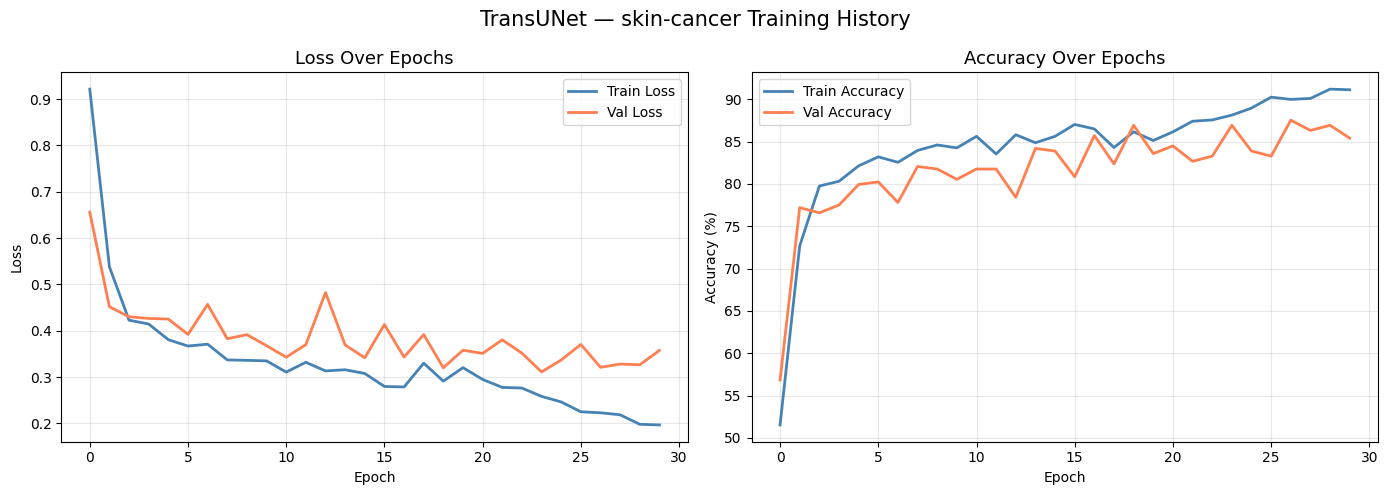

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/transunet_training_history.png


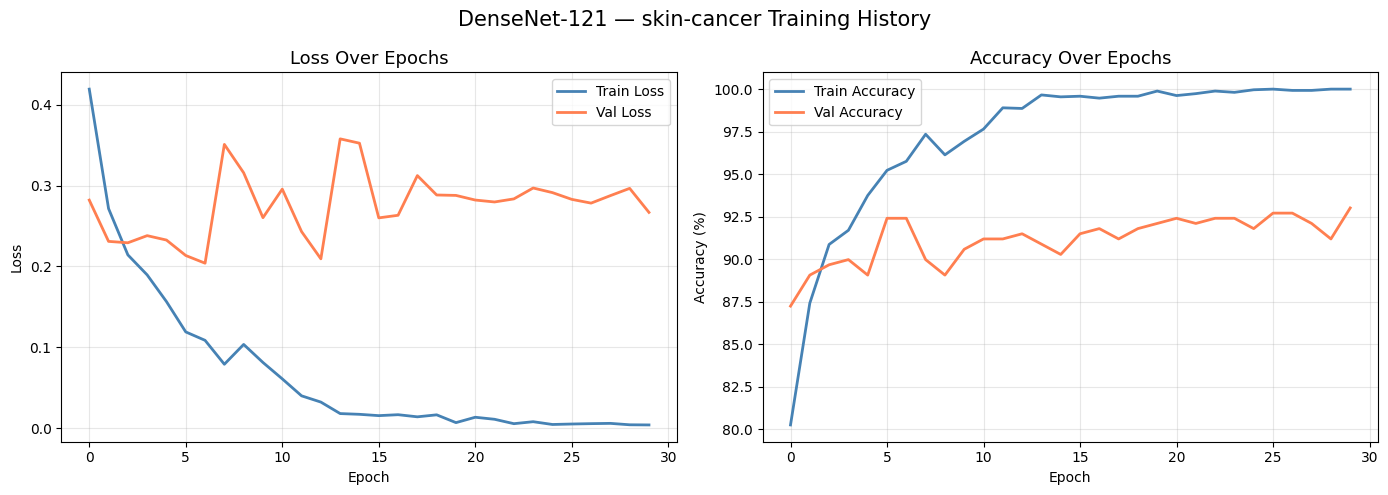

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/densenet-121_training_history.png


In [23]:
# Training curves
plot_training_history(transunet_history, 'TransUNet')
plot_training_history(densenet_history,  'DenseNet-121')

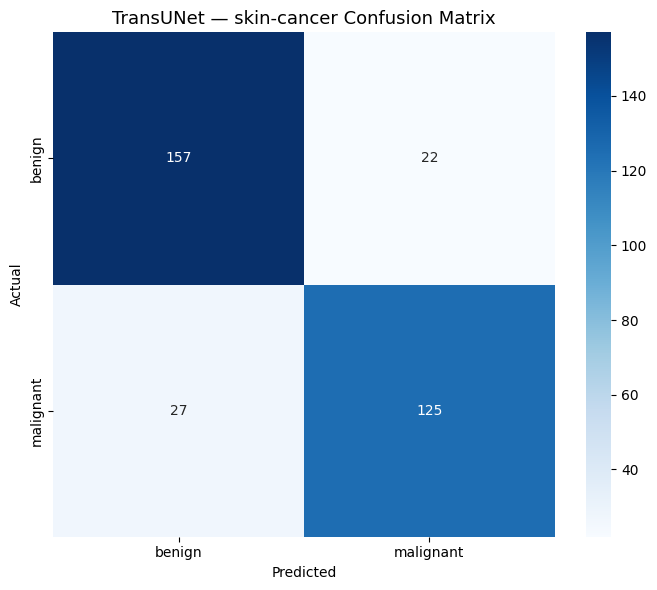

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/transunet_confusion_matrix.png


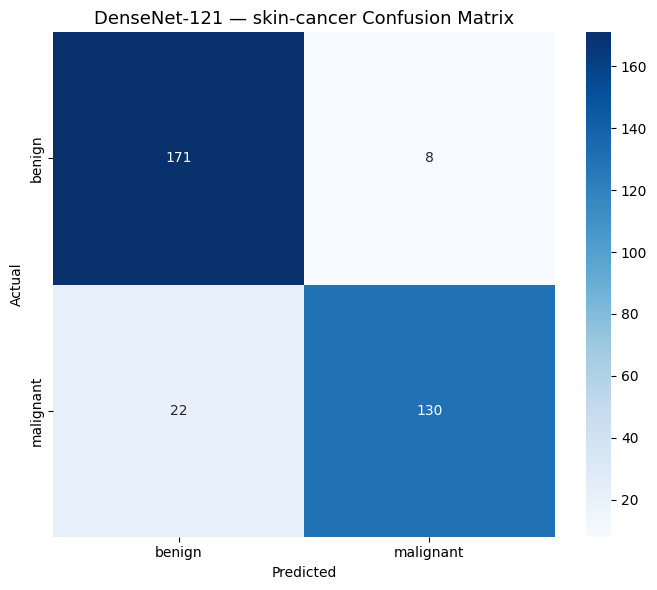

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/densenet-121_confusion_matrix.png


In [24]:
# Confusion matrices
plot_confusion_matrix(transunet_results)
plot_confusion_matrix(densenet_results)

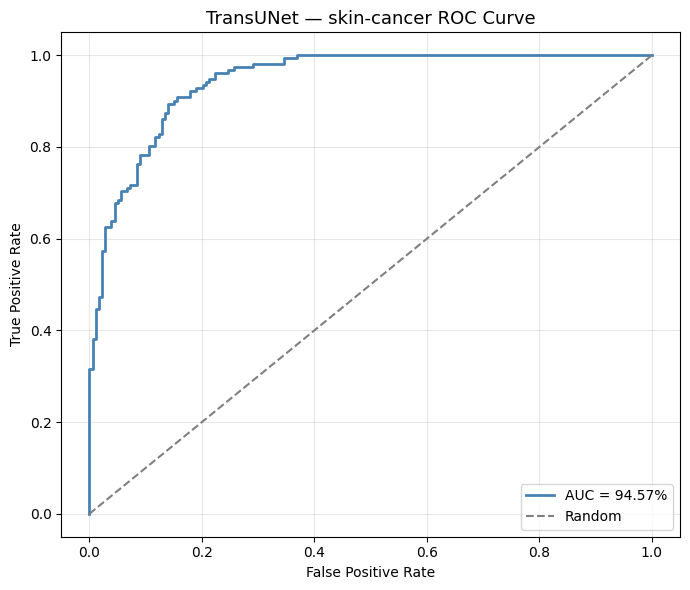

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/transunet_roc_curve.png


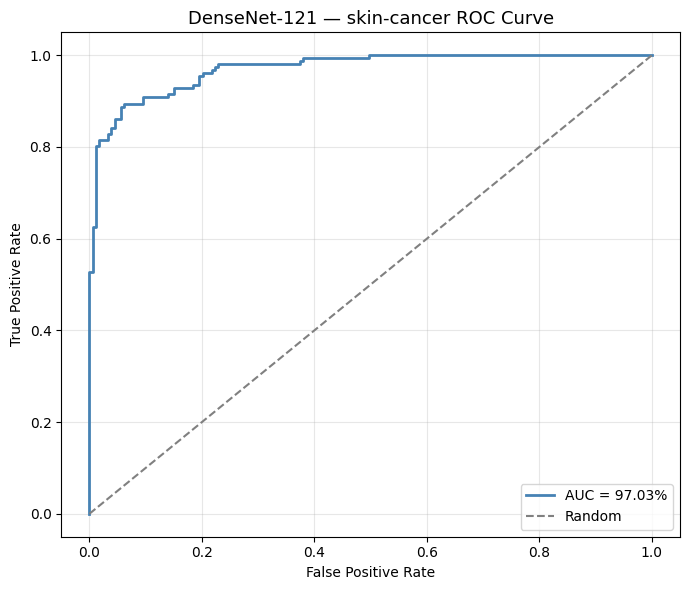

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/densenet-121_roc_curve.png


In [25]:
# ROC curves
plot_roc_curve(transunet_results)
plot_roc_curve(densenet_results)

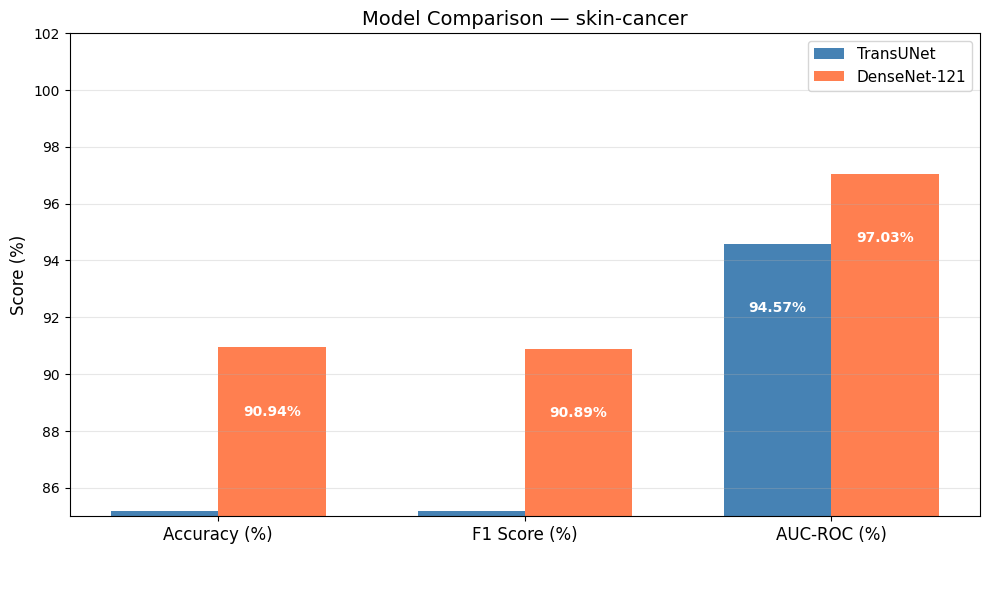

Saved: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/metric_images/comparison_chart.png


In [26]:
# Side-by-side comparison
plot_comparison([transunet_results, densenet_results])

In [27]:
# Final summary table
summary = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy (%)': f"{r['accuracy']:.2f}",
        'F1 Score (%)':  f"{r['f1']:.2f}",
        'AUC-ROC (%)':   f"{r['auc_roc']:.2f}",
    }
    for r in [transunet_results, densenet_results]
])
print(f'\n{DATASET_NAME} — Final Results')
print(summary.to_string(index=False))

summary_path = os.path.join(SAVE_DIR, f'{DATASET_NAME.lower()}_results_summary.csv')
summary.to_csv(summary_path, index=False)
print(f'\nSummary saved to: {summary_path}')


skin-cancer — Final Results
       Model Accuracy (%) F1 Score (%) AUC-ROC (%)
   TransUNet        85.20        85.17       94.57
DenseNet-121        90.94        90.89       97.03

Summary saved to: /content/drive/MyDrive/TransUNet_Classification/Results/skin-cancer/skin-cancer_results_summary.csv
